# <font color='green'>Covariance Matrices and Principal Component Analysis</font>

### We'll start off by importing what we need

In [1]:
import numpy as np
import numpy.linalg as npla

import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
%matplotlib inline

## Example of Calculating the Covariance Matrix

***Given a data set in the form of a matrix D (simple example here with 3 variables and 3 entries):***

## Let's take a look at some of the Properties of the Covariance Matrix

In [2]:
# Set outputs to 4 places after decimal, suppress scientific notation
np.set_printoptions(precision=4, suppress=True)   


# Made-up Data Set in matrix D 
D = np.array([[2 , 0 , 2], [ 4 , 1 , 4], [ 0 , 1 , 1]])
print("Data set matrix D:\n", D, '\n')

# Process is:
# 1. Find the mean of each column in the matrix D
# 2. Create an m-element row vector mT 
# 3. Create the matrix M that’s mT stacked n times.
# 4. Calculate (D – M), which is matrix D, but each entry has the mean removed (i.e. each entry is centered around its mean)
# 5. Calculate the covariance of matrix C (you can do this in 2 ways) 

mu = np.mean( D , axis=0)            # gives you a vector
n = D.shape[0]
M = np.outer( np.ones((n , 1)), mu)  # gives you a matrix M

Z = D - M

# SIMPLE WAY (using the built-in Covariance function):
C = np.cov(Z.T, bias=True)

print("Covariance Matrix using np.cov():\n", C, '\n')


# "FULL" WAY (using math):
C = 1/n * Z.T@Z

print("Covariance Matrix use direct math:\n", C)


Data set matrix D:
 [[2 0 2]
 [4 1 4]
 [0 1 1]] 

Covariance Matrix using np.cov():
 [[2.6667 0.     2.    ]
 [0.     0.2222 0.1111]
 [2.     0.1111 1.5556]] 

Covariance Matrix use direct math:
 [[2.6667 0.     2.    ]
 [0.     0.2222 0.1111]
 [2.     0.1111 1.5556]]


In [3]:
# C is supposed to symmetrical
print("Symmetry results:", np.all(C - C.T <= 1e-15) )

# C has a rank of AT MOST n-1
print("Rank of C::::::::", npla.matrix_rank(C))

# The determinant of C is zero
print("Determinant of C:", npla.det(C))

# Look at the significant values and also the eigenvalues of C:
print("\n---Sigma and eigenvalues---")

e, d = npla.eig(C)
U, s, Vt = npla.svd(C)

print("Eigenvalues::::::::", e)
print("Sorted eigenvalues:", e[e.argsort()[::-1].real])
print("Singular Values::::", s)

Symmetry results: True
Rank of C:::::::: 2
Determinant of C: 1.1102230246251573e-16

---Sigma and eigenvalues---
Eigenvalues:::::::: [4.188  0.     0.2565]
Sorted eigenvalues: [4.188  0.2565 0.    ]
Singular Values:::: [4.188  0.2565 0.    ]


# <font color='blue'>Let's take a look at an example of a data set</font>

The *iris data set* is a familiar example in data mining.  It shows measurements for three kinds of iris flowers: *Setosa*, *Virginica*, and *Versicolor*.  You can obtain this data set from the `datasets` module in the **SciKit-Learn** library.  

The data set has four *features* or *attributes* for each iris flower: Sepal Length, Sepal Width, Petal Length, and Petal Width.  An additional vector contains the individual classes.

![pic of irises](iris.png)

Reproduced from https://rpubs.com/vidhividhi/irisdataeda.

In [4]:
# Loading the iris data set.
from sklearn import datasets

iris = datasets.load_iris()

D = iris.data     # Contains features for 150 specimens (samples).
y = iris.target   # Contains the target class for each specimen.

(n, p) = D.shape
print("Data set loaded: {} specimens and {} columns.".format(n,p))
print("i.e. Data set matrix D is {}x{}.\n".format(n,p))

# Sneak peek at the contents of D and y.
print("Here's a few lines from the data set:")
print( "Sepal\tSepal\tPetal\tPetal\tIris" )
print( "Length\tWidth\tLength\tWidth\tSpecies" )

for i in range( 0, n, 15 ):
    for j in range( p ):
        print( D[i, j], end="\t" )
    print( y[i] )

Data set loaded: 150 specimens and 4 columns.
i.e. Data set matrix D is 150x4.

Here's a few lines from the data set:
Sepal	Sepal	Petal	Petal	Iris
Length	Width	Length	Width	Species
5.1	3.5	1.4	0.2	0
5.7	4.4	1.5	0.4	0
4.8	3.1	1.6	0.2	0
4.8	3.0	1.4	0.3	0
5.0	2.0	3.5	1.0	1
6.6	3.0	4.4	1.4	1
5.5	2.6	4.4	1.2	1
7.6	3.0	6.6	2.1	2
6.9	3.2	5.7	2.3	2
7.7	3.0	6.1	2.3	2


#### First, we want to standardize the data matrix using *z-scores*
This is a step that helps us, among other things, center our final projection

In [5]:
# Let's compute the covariance of Petal Width and Petal Length.
x = D[:, 2]         # Petal length, which is in column 2 of the data set
y = D[:, 3]         # Petal width, which is in column 3 of the data set
# print(x)
# print(y)

mu_x = np.mean( x ) # Respective means.
mu_y = np.mean( y )
# print(mu_x)
# print(mu_y)

print( "Covariance of columns x and y is:", 1/(n - 1) * (x - mu_x).T @ (y - mu_y) )

Covariance of columns x and y is: 1.2956093959731543


[-0.3631  0.4158]


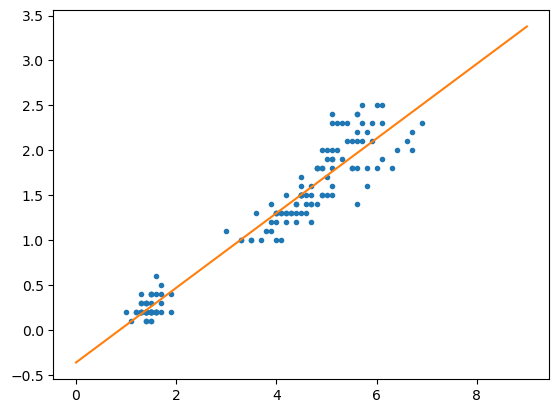

In [6]:
# Let's find the regression line through the data, y = a + b*x, using least squares.

n = D.shape[0]
A = np.ones( (n, 2) )
A[:, 1] = x
coeff = npla.lstsq(A, y, rcond = None)[0]
print(coeff)

# We can plot this too!
x_line = np.linspace(0, 9, num = 10) 
y_line = coeff[0] + coeff[1]*x_line
plt.plot(x, y, '.')
plt.plot(x_line, y_line, '-')

## Let's plot Petal Width vs. Petal Length for all 3 types of Irises

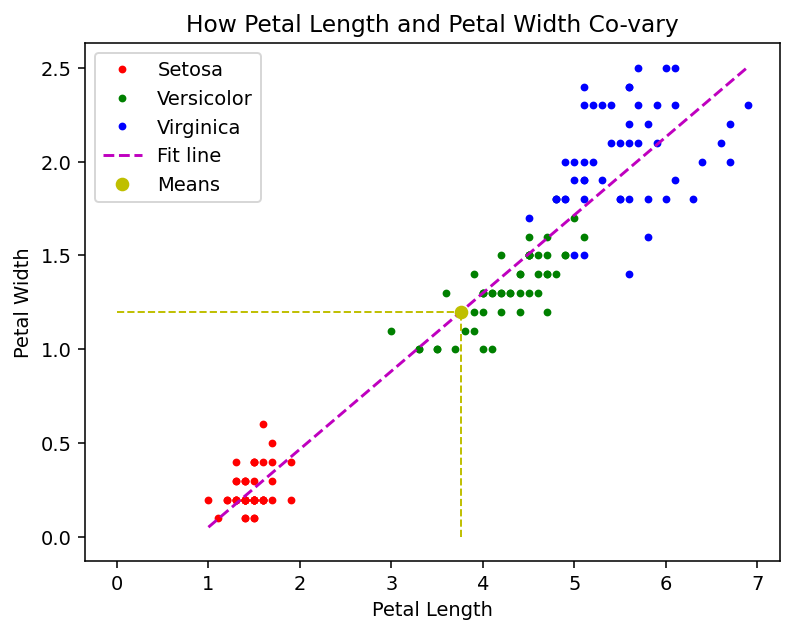

In [7]:
# Defining some indices.
setosaIdx = range( 0, 50 )         # The target classes appear in three consecutive ranges.
versicolorIdx = range( 50, 100 )
virginicaIdx = range( 100, 150 )

# Plotting Petal Width against Petal Length.
fig = plt.figure(dpi=140)
ax = fig.add_subplot( 111 )

ax.set_title( "How Petal Length and Petal Width Co-vary" )

ax.plot( x[setosaIdx], y[setosaIdx], "r.", label="Setosa" )
ax.plot( x[versicolorIdx], y[versicolorIdx], "g.", label="Versicolor" )
ax.plot( x[virginicaIdx], y[virginicaIdx], "b.", label="Virginica" )

x_min_max = np.array( [np.min( x ), np.max( x )] )
ax.plot( x_min_max, coeff[0] + coeff[1] * x_min_max, "m--", label="Fit line" )

ax.plot( mu_x, mu_y, "yo", label="Means" )
ax.plot( [mu_x, mu_x], [0, mu_y], "y--", linewidth=1 )
ax.plot( [0, mu_x], [mu_y, mu_y], "y--", linewidth=1 )

ax.set_xlabel( "Petal Length" )
ax.set_ylabel( "Petal Width" )
plt.legend(loc='upper left')
plt.show()

# The previous example works fine *without* having to use PCA, but you can't count on all data sets being this "nice"!

### Let's re-run the analysis using PCA this time

## THEORETICAL BACKGROUND:

**Principal Component Analysis** is based on the **singular value decomposition** of the covariance matrix $C$ of a data set $D$. If $C = USV^T$, then the columns of $U$ (or $V$) are the **principal components** of $D$.  

If we take the $k$ first principal components, we can get the approximation

$$\mathbf{d} \approx \mathbf{\mu} + a_0\mathbf{e}_0 + a_1\mathbf{e}_1 + \cdots + a_{k-1}\mathbf{e}_{k-1},$$

where the coefficients $a_i = \mathbf{x} \cdot \mathbf{e}_i$ are the "normal projections" of the centered data row vectors $\mathbf{x} = \mathbf{d} - \mathbf{\mu}$ onto the eigenvectors $\mathbf{e}_i$.  

Let $U^{(k)}$ be the $p$-by-$k$ matrix of first $k$ columns of $U$; then, we can write the previous approximation in matrix form for the whole data set $D$ as

$$D^{(k)} \approx M + (XU^{(k)})\left(U^{(k)}\right)^T,$$

where $M \in \mathbb{R}^{n\times p}$ is the matrix with the mean row vector $\mathbf{\mu}^T$ stacked $n$ times and $X = D - M$ is the $n$-by-$p$ matrix of centered data.  Notice that we can retrieve the original data set $D = D^{(p)}$ if we use all of the $p$ singular vectors in $U$.

The first principal component $\mathbf{e}_0$ has the property that $X\mathbf{e}_0$ has the *highest possible variance* among all linear combination of the features in $D$.  The second principal component $\mathbf{e}_1$ has the property that $X\mathbf{e}_1$ has the second highest possible variance among all linear combinations of the features in $D$ that are orthogonal to $\mathbf{e}_0$, and so forth.

When we apply PCA to the full iris data set, we are able to identify the main axes over which data varies the most.  Then, if we look at the components in those axes, we will see which features in the original data set $D$ get emphasized.

#### 1. Calculate the covariance matrix C from dataset D:

In [8]:
mu = np.mean( D, axis=0 )                     # 1-by-p row vector of column mean values.
M = np.outer( np.ones( (n, 1) ), mu )         # n-by-p matrix of stacked row mean vectors.
Z = (D - M)

# 4x4 covariance matrix, we're going to use bias=True b/c n is small
C = np.cov( Z.T , bias=True )                  

print( "Covariance of the iris data set" )
print( C )

Covariance of the iris data set
[[ 0.6811 -0.0422  1.2658  0.5128]
 [-0.0422  0.1887 -0.3275 -0.1208]
 [ 1.2658 -0.3275  3.0955  1.287 ]
 [ 0.5128 -0.1208  1.287   0.5771]]


#### 2. Find the SVD components of C
Finding the SVD components of the covariant matrix is often useful.

In this case, because **C** is Symmetrical, positive semidefinite (SPSD), 
then its eigenvalues are its **singular values**.

Furthermore, the matrix **U** is also its eigenvectors, per the order of the singular values.

In [9]:
U, sigma, Vt = npla.svd( C )       # U and V are equivalent: they contain the eigenvectors of C.

print( "\nShowing the first two principal components (the first 2 columns):\n" )
print( "Matrix U:\n", U, '\n')


Showing the first two principal components (the first 2 columns):

Matrix U:
 [[-0.3614 -0.6566  0.582   0.3155]
 [ 0.0845 -0.7302 -0.5979 -0.3197]
 [-0.8567  0.1734 -0.0762 -0.4798]
 [-0.3583  0.0755 -0.5458  0.7537]] 



#### 2b. Let's also find the e-values and e-vectors *just* to compare what we have...

In [10]:
evals, evecs = npla.eig( C )
print( "e-vals:       ", evals.real )
print( "sigma:        ", sigma.real )

e-vals:        [4.2001 0.2411 0.0777 0.0237]
sigma:         [4.2001 0.2411 0.0777 0.0237]


**Since eigenvalues are *not always* presented in sorted fashion by `numpy`, then whenever we want to compare them to sigma values, we need to sort them in similar fashion to sigma (i.e. in descending order)**

In [11]:
print( "sorted e-vals:", evals[evals.argsort()[::-1]].real)

sorted e-vals: [4.2001 0.2411 0.0777 0.0237]


**Note that eigenvectors may be equal to, but +/-, the columns in matrix U:**

In [12]:
print( "e-vectors:\n", evecs, '\n')
print( "Matrix U:\n", U, '\n')

# Sorting eigenvectors - same reason as sorting eigenvalues:
sorted_evecs =  evecs[:,evals.argsort()[::-1]]
print( "sorted e-vectors:\n", sorted_evecs, '\n')

# Are these last 2 equal?
print("difference in norms:", npla.norm(U) - npla.norm(sorted_evecs))

e-vectors:
 [[ 0.3614 -0.6566 -0.582   0.3155]
 [-0.0845 -0.7302  0.5979 -0.3197]
 [ 0.8567  0.1734  0.0762 -0.4798]
 [ 0.3583  0.0755  0.5458  0.7537]] 

Matrix U:
 [[-0.3614 -0.6566  0.582   0.3155]
 [ 0.0845 -0.7302 -0.5979 -0.3197]
 [-0.8567  0.1734 -0.0762 -0.4798]
 [-0.3583  0.0755 -0.5458  0.7537]] 

sorted e-vectors:
 [[ 0.3614 -0.6566 -0.582   0.3155]
 [-0.0845 -0.7302  0.5979 -0.3197]
 [ 0.8567  0.1734  0.0762 -0.4798]
 [ 0.3583  0.0755  0.5458  0.7537]] 

difference in norms: 6.661338147750939e-16


**Testing orthogonality of the eigenvectors/U columns can be done like this:**

In [13]:
#shows orthogonality of eigenvectors of matrix C:

dotprods = []
for i in range(C.shape[0]):
    for j in range(C.shape[0]):
        if i != j:
            dotprods.append((evecs[i].dot(evecs[j])))
            
print("All dot product values:\n", dotprods, '\n')

print("Are all the numbers in there practically zero?", np.all(np.abs(dotprods) <= 1e-15))

All dot product values:
 [6.862016661416246e-16, 4.32993603389524e-16, -5.377994313683564e-16, 6.862016661416246e-16, -3.7225632892059214e-16, 8.669258216565567e-17, 4.32993603389524e-16, -3.7225632892059214e-16, -1.9445305710919227e-16, -5.377994313683564e-16, 8.669258216565567e-17, -1.9445305710919227e-16] 

Are all the numbers in there practically zero? True


#### 3. Examine the variability per singular value of C:

Understanding how much variability is explained by each principal component is very important

This is equivalent to the relative eigenvalues of the principal components:

In [14]:
sumEvals = sum(sigma)
accum = 0
for i in range(C.shape[0]):
    accum += 100*sigma[i]/sumEvals
    print("Variation that eigenvalue%d (i.e. PC%d) accounts for: %.2f%% var. Accumulated: %.2f%%"%
          (i, i, 100*sigma[i]/sumEvals, accum))

Variation that eigenvalue0 (i.e. PC0) accounts for: 92.46% var. Accumulated: 92.46%
Variation that eigenvalue1 (i.e. PC1) accounts for: 5.31% var. Accumulated: 97.77%
Variation that eigenvalue2 (i.e. PC2) accounts for: 1.71% var. Accumulated: 99.48%
Variation that eigenvalue3 (i.e. PC3) accounts for: 0.52% var. Accumulated: 100.00%


#### Plotting this information is even nicer...
This is called a ***Scree Plot***:

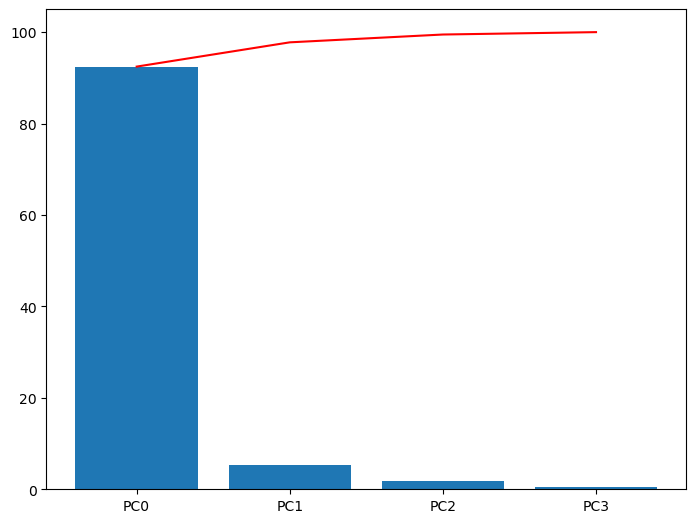

In [15]:
# Data to plot (from the previous calculation)
# can you think of a way to automate this regardless of data matrix???
numList = [92.462, 5.307, 1.7103, 0.5212]
accumList = [92.462, 97.769, 99.479, 100.]

# Plotting the variability info (Scree Plot)
fig = plt.figure()
plt.ylim(0,100)
ax = fig.add_axes([0,0,1,1])
ax.bar(['PC0', 'PC1', 'PC2', 'PC3'], numList)
plt.plot(accumList, 'r-')
plt.show()

## Dimensionality Reduction by PCA

Using the normal projections $a_0, a_1, ..., a_{k-1}$ of $\mathbf{x} = \mathbf{d} - \mu$ onto the first $k$ principal components $\mathbf{e}_0, \mathbf{e}_1, ..., \mathbf{e}_{k-1}$, we can obtain a low-dimensional view (and further usage) of any row vector $\mathbf{d}^T$ in $D$.

In this low-dimensional view of the data set, instead of $p$ coordinates for every sample $\mathbf{d}$, we now have $k$ coordinates: $a_0, a_1, ..., a_{k-1}$.

Let's use the first two principal components of the iris data set to obtain a **two-dimensional** view of its samples.




### <font color='red'>Everything up until here has been preparation to explain concepts.</font>
### <font color='red'>We'll run the whole thing from the beginning!</font>
**i.e. this is all the code needed to run PCA from a data set...**

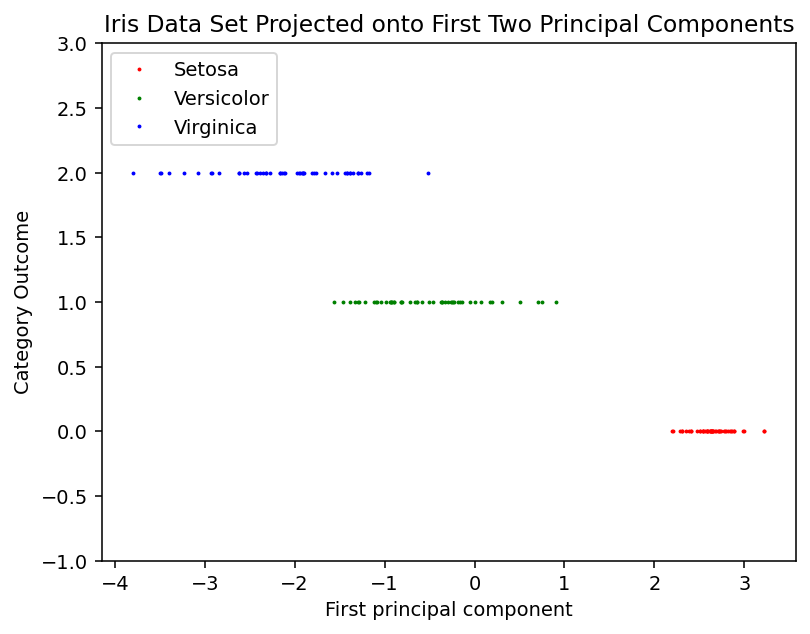

In [16]:
# Get the dataset

iris = datasets.load_iris()
D = iris.data     # Contains features for 150 specimens (samples).
y = iris.target   # Contains the target class for each specimen.

# Standardize D into matrix Z
mu = np.mean( D, axis=0 )                     # 1-by-p row vector of column mean values.
M = np.outer( np.ones( (n, 1) ), mu )         # n-by-p matrix of stacked row mean vectors.
Z = (D-M)

# Compute the covariance matrix of the iris data set (standardized).
C = np.cov( Z.T)

# Perform PCA on C.
U, sigma, Vt = npla.svd( C )

principalComponent0, principalComponent1 = U[:,0], U[:,1]

# Project onto two first principal components (together, they explain about 97.8% of the variability)
# This is a centered/standardized version of our data matrix 
# but now each observation is a combination of the original variables, 
# where the weights are determined by the eigenvector.
x0 = Z @ principalComponent0
# x1 = Z @ principalComponent1
x1 = y

# Plotting projected data.
fig = plt.figure(dpi=140)
ax = fig.add_subplot( 111 )
ax.set_title( "Iris Data Set Projected onto First Two Principal Components" )
ax.plot( x0[y == 0], x1[y == 0], "r.", markersize=2, label="Setosa" )
ax.plot( x0[y == 1], x1[y == 1], "g.", markersize=2, label="Versicolor" )
ax.plot( x0[y == 2], x1[y == 2], "b.", markersize=2, label="Virginica" )
ax.set_xlabel( "First principal component" )
ax.set_ylabel( "Category Outcome" )
plt.legend(loc='upper left')
# plt.ylim([-6,6])
plt.ylim([-1,3])
plt.show()